エラー: result.csv が見つかりません。スクリプトと同じディレクトリに配置してください。


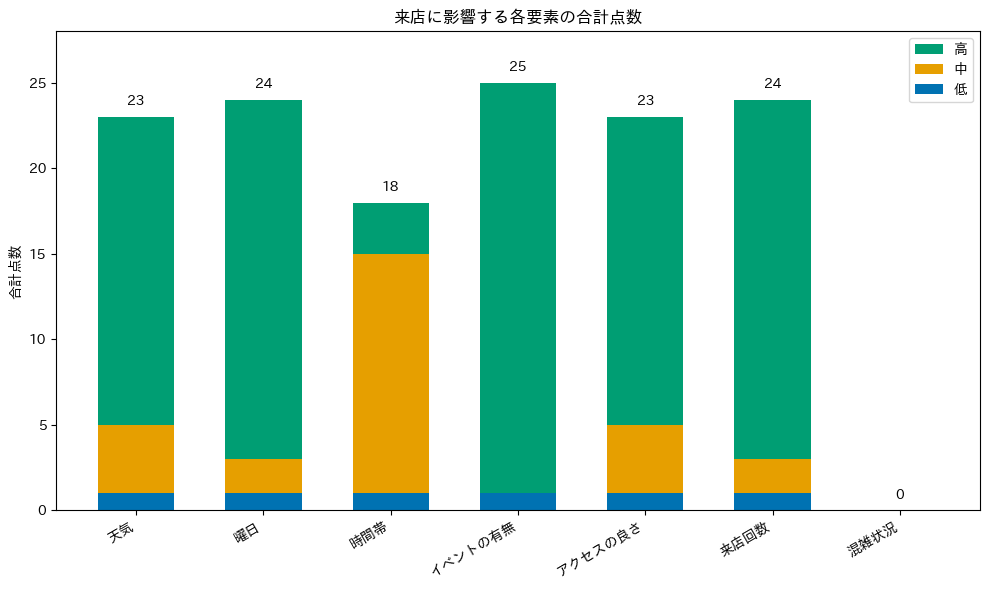

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# -----------------------------
# 🔽 CSVファイルの読み込み
# -----------------------------
# ローカルのCSVファイルを指定
path_csv = 'result.csv' 

try:
    df = pd.read_csv(path_csv)
except FileNotFoundError:
    print(f"エラー: {path_csv} が見つかりません。スクリプトと同じディレクトリに配置してください。")
    exit()


# -----------------------------
# 🔽 評価対象の要素（最後の7列）
# -----------------------------
elements = [
    "天気",          # 天気
    "曜日",        # 曜日
    "時間帯",        # 時間帯
    "イベントの有無",  # イベントの有無
    "アクセスの良さ",   # アクセスの良さ
    "来店回数",    # 来店回数
    "混雑状況"       # 混雑状況
]

# CSVから最後の7列を抽出
eval_df = df.iloc[:, -7:]
eval_df.columns = elements

# -----------------------------
# 🔽 スコア換算（1:Low=1点, 2:Medium=2点, 3:High=3点）
# -----------------------------
score_df = pd.DataFrame({
    '1': (eval_df == 1).sum() * 1,
    '2': (eval_df == 2).sum() * 2,
    '3': (eval_df == 3).sum() * 3
}, index=elements)

# 合計点
total_scores = score_df.sum(axis=1)

# -----------------------------
# 🔽 グラフ作成（積み上げ + 合計点表示）
# -----------------------------
x = np.arange(len(elements))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 6))

bar1 = ax.bar(x, score_df['1'], width, label='低', color='#0072B2')
bar2 = ax.bar(x, score_df['2'], width, bottom=score_df['1'], label='中', color='#E69F00')
bar3 = ax.bar(x, score_df['3'], width, bottom=score_df['1'] + score_df['2'], label='高', color='#009E73')

# 合計点ラベル
for i, total in enumerate(total_scores):
    ax.text(x[i], total + 0.5, str(int(total)), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, total_scores.max() + 3)

# ラベル・装飾
ax.set_ylabel('合計点数')
ax.set_title('来店に影響する各要素の合計点数')
ax.set_xticks(x)
ax.set_xticklabels(elements, rotation=30, ha='right') # ha='right' を追加してラベルが見やすくなるように調整
ax.legend(handles=[bar3, bar2, bar1], labels=['高', '中', '低'])

plt.tight_layout()
plt.show()